In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Setup complete")

Setup complete


In [18]:
df = pd.read_csv("../data/processed/merged_hourly.csv", parse_dates=["time"])

print(f"Shape: {df.shape}")
print(f"Range: {df['time'].min()} to {df['time'].max()}")
df.head()

Shape: (31656, 16)
Range: 2023-01-01 00:00:00 to 2026-08-11 23:00:00


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m
0,2023-01-01 00:00:00,83.6,52.4,1013.0,40.5,44.3,82.0,132,17.9,85,15.3,0.0,1020.0,0,10.9,304
1,2023-01-01 01:00:00,78.2,48.5,905.0,34.3,38.6,84.0,134,17.6,85,15.0,0.0,1019.4,0,11.2,312
2,2023-01-01 02:00:00,72.2,44.1,761.0,27.4,31.6,85.0,135,17.0,86,14.6,0.0,1018.9,0,10.3,324
3,2023-01-01 03:00:00,66.4,39.9,655.0,23.7,27.4,85.0,136,16.2,87,13.9,0.0,1018.3,0,8.2,331
4,2023-01-01 04:00:00,61.5,36.4,547.0,21.0,23.7,84.0,136,15.8,86,13.5,0.0,1017.8,0,9.8,6


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31656 entries, 0 to 31655
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  31656 non-null  datetime64[ns]
 1   pm10                  31656 non-null  float64       
 2   pm2_5                 31656 non-null  float64       
 3   carbon_monoxide       31656 non-null  float64       
 4   nitrogen_dioxide      31656 non-null  float64       
 5   sulphur_dioxide       31656 non-null  float64       
 6   ozone                 31656 non-null  float64       
 7   us_aqi                31656 non-null  int64         
 8   temperature_2m        31656 non-null  float64       
 9   relative_humidity_2m  31656 non-null  int64         
 10  dew_point_2m          31656 non-null  float64       
 11  precipitation         31656 non-null  float64       
 12  surface_pressure      31656 non-null  float64       
 13  cloud_cover     

In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time,31656,2024-10-21 11:30:00.000000256,2023-01-01 00:00:00,2023-11-26 17:45:00,2024-10-21 11:30:00,2025-09-16 05:15:00,2026-08-11 23:00:00,NaN
pm10,31656.0,62.525051,3.7,39.5,53.7,74.5,504.8,37.375287
pm2_5,31656.0,29.160447,3.5,19.2,24.9,34.0,339.0,16.621198
carbon_monoxide,31656.0,470.788381,46.0,209.0,315.0,585.0,5014.0,421.378911
nitrogen_dioxide,31656.0,19.796863,0.0,7.3,12.9,25.4,209.6,19.113326
sulphur_dioxide,31656.0,14.177786,0.3,6.0,11.5,18.3,260.1,12.299435
ozone,31656.0,73.366755,0.0,44.0,63.0,95.0,680.0,42.983545
us_aqi,31656.0,90.110911,41.0,72.0,82.0,100.0,297.0,27.468507
temperature_2m,31656.0,26.530582,8.9,23.7,27.5,29.9,41.6,4.859838
relative_humidity_2m,31656.0,66.038634,5.0,53.0,70.0,83.0,100.0,21.161501


In [21]:
aqi = df["us_aqi"]

print(f"Mean AQI:   {aqi.mean():.1f}")
print(f"Median AQI: {aqi.median():.1f}")
print(f"Min AQI:    {aqi.min():.0f}")
print(f"Max AQI:    {aqi.max():.0f}")
print()

bins = [0, 50, 100, 150, 200, 300, 500]
labels = ["Good", "Moderate", "Unhealthy (sensitive)", "Unhealthy", "Very unhealthy", "Hazardous"]
categories = pd.cut(aqi, bins=bins, labels=labels, right=True)

counts = categories.value_counts().reindex(labels)
percentages = (counts / len(aqi) * 100).round(1)

summary = pd.DataFrame({"hours": counts, "percent": percentages})
print(summary)

Mean AQI:   90.1
Median AQI: 82.0
Min AQI:    41
Max AQI:    297

                       hours  percent
us_aqi                               
Good                      64      0.2
Moderate               23806     75.2
Unhealthy (sensitive)   6156     19.4
Unhealthy               1481      4.7
Very unhealthy           149      0.5
Hazardous                  0      0.0


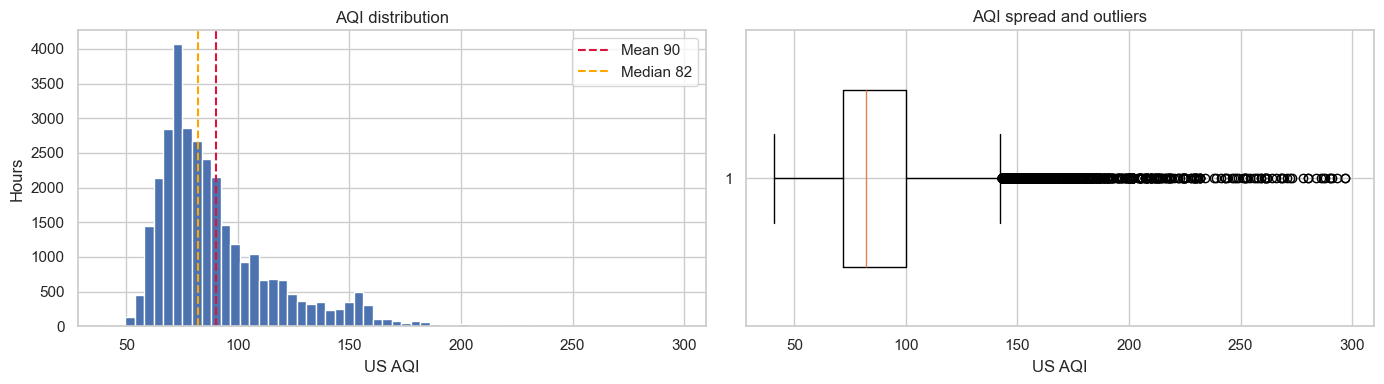

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["us_aqi"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["us_aqi"].mean(), color="crimson", linestyle="--", label=f"Mean {df['us_aqi'].mean():.0f}")
axes[0].axvline(df["us_aqi"].median(), color="orange", linestyle="--", label=f"Median {df['us_aqi'].median():.0f}")
axes[0].set_title("AQI distribution")
axes[0].set_xlabel("US AQI")
axes[0].set_ylabel("Hours")
axes[0].legend()

axes[1].boxplot(df["us_aqi"], vert=False, widths=0.6)
axes[1].set_title("AQI spread and outliers")
axes[1].set_xlabel("US AQI")

plt.tight_layout()
plt.show()

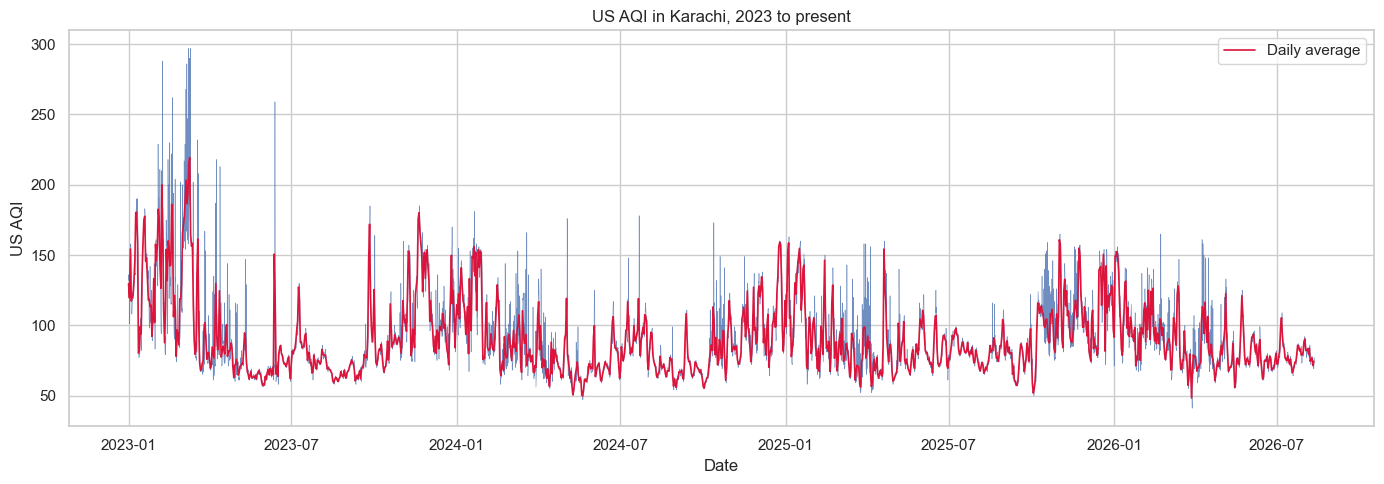

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["time"], df["us_aqi"], linewidth=0.4, color="#4C72B0", alpha=0.8)

daily = df.set_index("time")["us_aqi"].resample("D").mean()
ax.plot(daily.index, daily.values, linewidth=1.2, color="crimson", label="Daily average")

ax.set_title("US AQI in Karachi, 2023 to present")
ax.set_xlabel("Date")
ax.set_ylabel("US AQI")
ax.legend()

plt.tight_layout()
plt.show()

      mean  median  max
Jan  117.3   115.0  190
Feb  103.0    93.0  288
Mar   93.7    81.0  297
Apr   80.4    75.0  218
May   73.9    70.0  176
Jun   78.0    74.0  259
Jul   84.6    83.0  178
Aug   73.5    72.0  116
Sep   75.9    72.0  185
Oct   86.9    85.0  173
Nov  110.9   106.0  185
Dec  106.0   102.0  170


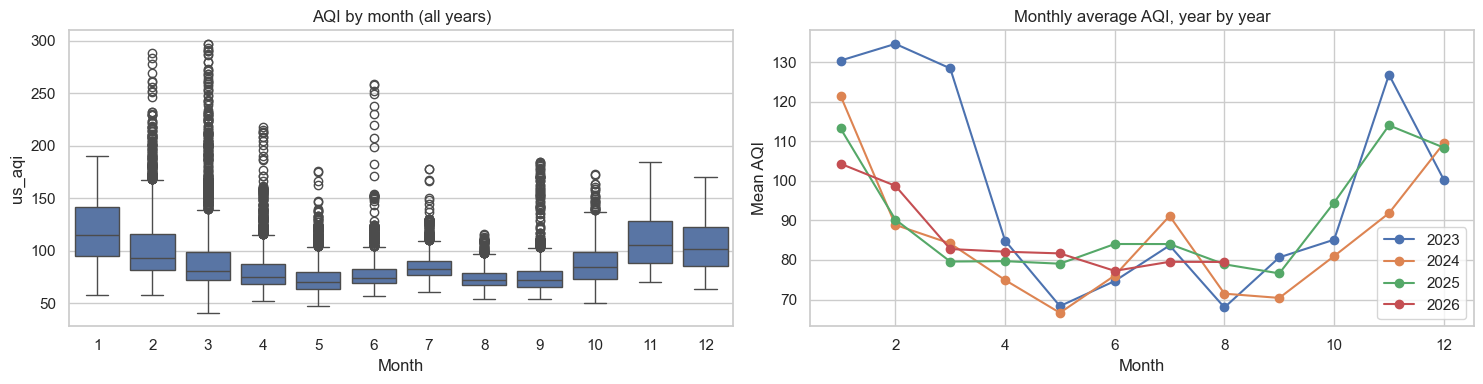

In [24]:
df["month"] = df["time"].dt.month
df["year"] = df["time"].dt.year

monthly = df.groupby("month")["us_aqi"].agg(["mean", "median", "max"]).round(1)
monthly.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
print(monthly)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(data=df, x="month", y="us_aqi", ax=axes[0], color="#4C72B0")
axes[0].set_title("AQI by month (all years)")
axes[0].set_xlabel("Month")

for yr in sorted(df["year"].unique()):
    subset = df[df["year"] == yr].groupby("month")["us_aqi"].mean()
    axes[1].plot(subset.index, subset.values, marker="o", label=str(yr))
axes[1].set_title("Monthly average AQI, year by year")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean AQI")
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
#autocorrelation
series = df.set_index("time")["us_aqi"]

lags_hours = [1, 3, 6, 12, 24, 48, 72, 96, 120, 168]
print("Autocorrelation of hourly AQI")
for lag in lags_hours:
    print(f"  lag {lag:>3}h ({lag/24:>4.1f} days): {series.autocorr(lag=lag):.3f}")

daily = series.resample("D").mean()
print()
print("Autocorrelation of DAILY average AQI")
for lag in range(1, 8):
    print(f"  lag {lag} day(s): {daily.autocorr(lag=lag):.3f}")

Autocorrelation of hourly AQI
  lag   1h ( 0.0 days): 0.990
  lag   3h ( 0.1 days): 0.948
  lag   6h ( 0.2 days): 0.896
  lag  12h ( 0.5 days): 0.832
  lag  24h ( 1.0 days): 0.754
  lag  48h ( 2.0 days): 0.621
  lag  72h ( 3.0 days): 0.542
  lag  96h ( 4.0 days): 0.492
  lag 120h ( 5.0 days): 0.460
  lag 168h ( 7.0 days): 0.423

Autocorrelation of DAILY average AQI
  lag 1 day(s): 0.835
  lag 2 day(s): 0.677
  lag 3 day(s): 0.590
  lag 4 day(s): 0.533
  lag 5 day(s): 0.501
  lag 6 day(s): 0.475
  lag 7 day(s): 0.459


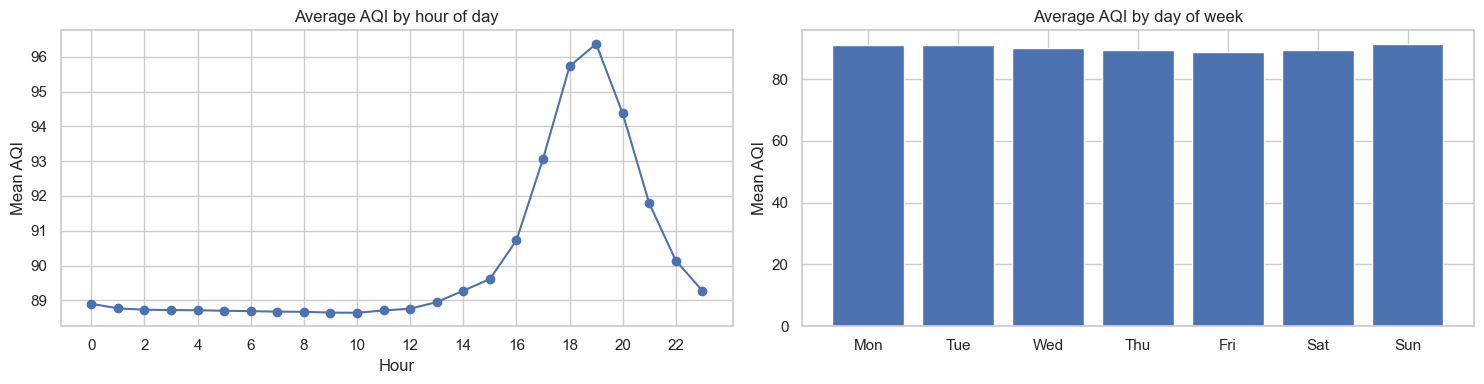

In [26]:
df["hour"] = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

hourly_avg = df.groupby("hour")["us_aqi"].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker="o", color="#4C72B0")
axes[0].set_title("Average AQI by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean AQI")
axes[0].set_xticks(range(0, 24, 2))

dow_avg = df.groupby("dayofweek")["us_aqi"].mean()
axes[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow_avg.values, color="#4C72B0")
axes[1].set_title("Average AQI by day of week")
axes[1].set_ylabel("Mean AQI")

plt.tight_layout()
plt.show()

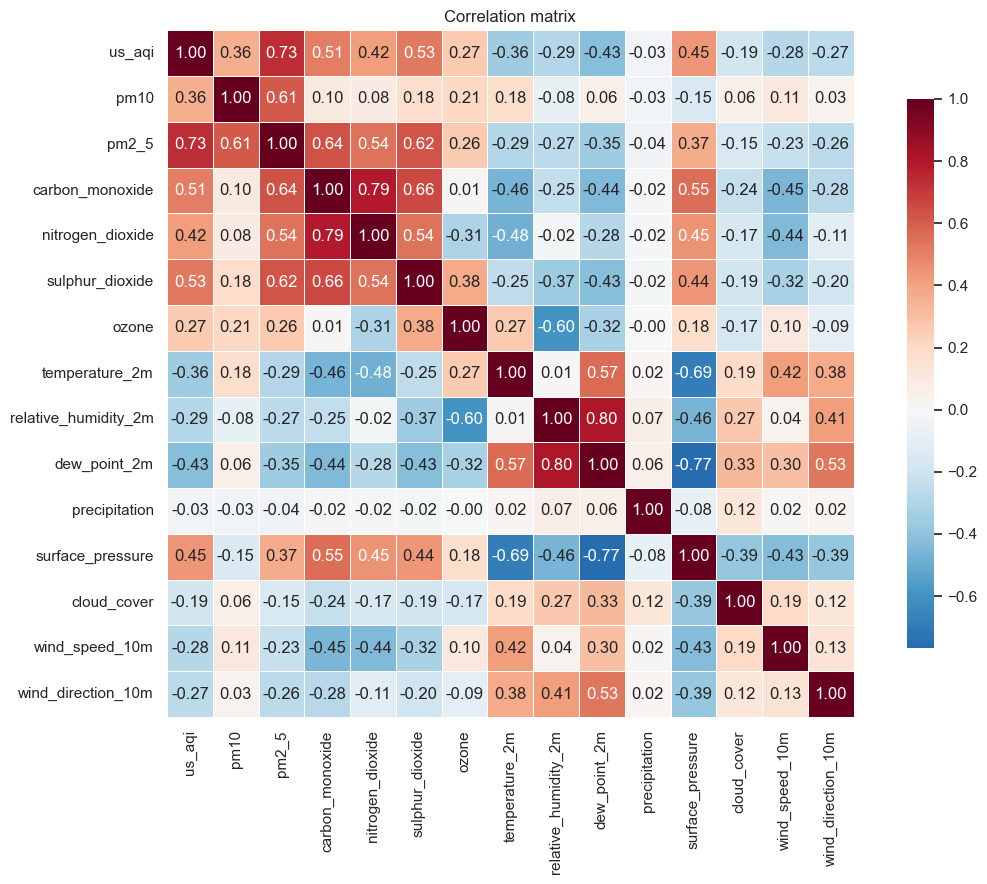

In [27]:
weather_cols = ["temperature_2m", "relative_humidity_2m", "dew_point_2m",
                "precipitation", "surface_pressure", "cloud_cover",
                "wind_speed_10m", "wind_direction_10m"]
pollutant_cols = ["pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide",
                  "sulphur_dioxide", "ozone"]

corr = df[["us_aqi"] + pollutant_cols + weather_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

In [28]:
target_corr = df[pollutant_cols + weather_cols].corrwith(df["us_aqi"]).sort_values(key=abs, ascending=False)

print("Correlation with us_aqi, strongest first")
print("-" * 45)
for name, value in target_corr.items():
    bar = "#" * int(abs(value) * 40)
    print(f"{name:>22}  {value:>6.3f}  {bar}")

Correlation with us_aqi, strongest first
---------------------------------------------
                 pm2_5   0.732  #############################
       sulphur_dioxide   0.529  #####################
       carbon_monoxide   0.511  ####################
      surface_pressure   0.447  #################
          dew_point_2m  -0.429  #################
      nitrogen_dioxide   0.418  ################
                  pm10   0.361  ##############
        temperature_2m  -0.359  ##############
  relative_humidity_2m  -0.295  ###########
        wind_speed_10m  -0.283  ###########
    wind_direction_10m  -0.268  ##########
                 ozone   0.265  ##########
           cloud_cover  -0.194  #######
         precipitation  -0.033  #


In [29]:
daily = df.set_index("time").resample("D").agg({
    "us_aqi": ["mean", "max", "min"],
    "pm2_5": "mean",
    "pm10": "mean",
    "carbon_monoxide": "mean",
    "nitrogen_dioxide": "mean",
    "sulphur_dioxide": "mean",
    "ozone": "mean",
    "temperature_2m": ["mean", "max", "min"],
    "relative_humidity_2m": "mean",
    "surface_pressure": "mean",
    "cloud_cover": "mean",
    "wind_speed_10m": ["mean", "max"],
    "wind_direction_10m": "mean",
})

daily.columns = ["_".join(col).strip() for col in daily.columns]
daily = daily.reset_index()

print(f"Shape: {daily.shape}")
print(f"Range: {daily['time'].min().date()} to {daily['time'].max().date()}")
print()
print(daily.columns.tolist())
daily.head()

Shape: (1319, 19)
Range: 2023-01-01 to 2026-08-11

['time', 'us_aqi_mean', 'us_aqi_max', 'us_aqi_min', 'pm2_5_mean', 'pm10_mean', 'carbon_monoxide_mean', 'nitrogen_dioxide_mean', 'sulphur_dioxide_mean', 'ozone_mean', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'cloud_cover_mean', 'wind_speed_10m_mean', 'wind_speed_10m_max', 'wind_direction_10m_mean']


,time,us_aqi_mean,us_aqi_max,us_aqi_min,pm2_5_mean,pm10_mean,carbon_monoxide_mean,nitrogen_dioxide_mean,sulphur_dioxide_mean,ozone_mean,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,surface_pressure_mean,cloud_cover_mean,wind_speed_10m_mean,wind_speed_10m_max,wind_direction_10m_mean
0,2023-01-01,129.583333,136,110,38.462500,69.537500,782.708333,36.375000,33.408333,84.916667,19.875000,25.1,14.6,65.375000,1018.354167,0.833333,9.729167,16.4,245.750000
1,2023-01-02,119.416667,152,101,59.991667,98.883333,905.708333,47.270833,49.383333,71.708333,19.725000,25.6,14.5,51.583333,1017.987500,15.875000,11.641667,15.0,94.666667
2,2023-01-03,154.291667,158,142,51.512500,77.683333,542.708333,25.300000,27.175000,80.125000,19.750000,25.4,14.7,36.416667,1020.408333,26.041667,16.462500,19.5,37.875000
3,2023-01-04,117.208333,140,108,40.720833,60.787500,466.625000,18.037500,25.858333,94.541667,18.866667,24.1,14.5,33.041667,1021.045833,0.000000,20.275000,26.3,47.750000
4,2023-01-05,119.958333,124,113,43.608333,63.775000,487.625000,14.445833,28.491667,103.041667,17.487500,22.8,12.8,31.666667,1021.066667,9.250000,19.975000,29.3,48.916667


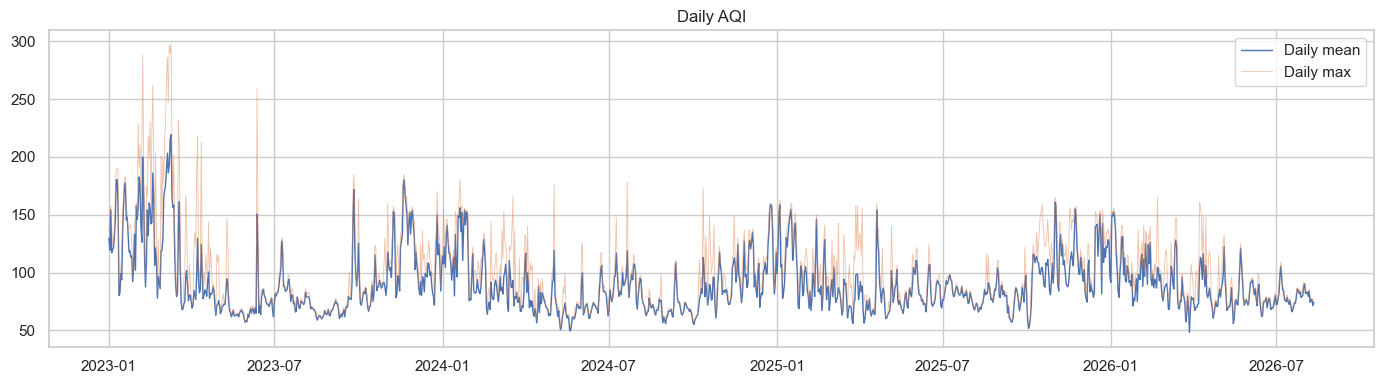

       us_aqi_mean  us_aqi_max
count       1319.0      1319.0
mean          90.1       101.7
std           25.8        34.7
min           48.3        52.0
25%           72.3        77.0
50%           82.8        92.0
75%          100.1       119.0
max          219.3       297.0


In [30]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily["time"], daily["us_aqi_mean"], linewidth=1, label="Daily mean")
ax.plot(daily["time"], daily["us_aqi_max"], linewidth=0.6, alpha=0.5, label="Daily max")
ax.set_title("Daily AQI")
ax.legend()
plt.tight_layout()
plt.show()

print(daily[["us_aqi_mean", "us_aqi_max"]].describe().round(1))

In [33]:
df_wind = df.copy()
df_wind["wind_dir_sin"] = np.sin(np.radians(df_wind["wind_direction_10m"]))
df_wind["wind_dir_cos"] = np.cos(np.radians(df_wind["wind_direction_10m"]))

daily = df_wind.set_index("time").resample("D").agg({
    "us_aqi": ["mean", "max", "min"],
    "pm2_5": "mean",
    "pm10": "mean",
    "carbon_monoxide": "mean",
    "nitrogen_dioxide": "mean",
    "sulphur_dioxide": "mean",
    "ozone": "mean",
    "temperature_2m": ["mean", "max", "min"],
    "relative_humidity_2m": "mean",
    "surface_pressure": "mean",
    "cloud_cover": "mean",
    "wind_speed_10m": ["mean", "max"],
    "wind_dir_sin": "mean",
    "wind_dir_cos": "mean",
})

daily.columns = ["_".join(col).strip() for col in daily.columns]
daily = daily.reset_index()

daily["month"] = daily["time"].dt.month
daily["month_sin"] = np.sin(2 * np.pi * daily["month"] / 12)
daily["month_cos"] = np.cos(2 * np.pi * daily["month"] / 12)
daily["dayofyear"] = daily["time"].dt.dayofyear

print(f"Shape: {daily.shape}")
print(daily[["time", "month", "month_sin", "month_cos", "wind_dir_sin_mean", "wind_dir_cos_mean"]].head())

Shape: (1319, 24)
        time  month  month_sin  month_cos  wind_dir_sin_mean  wind_dir_cos_mean
0 2023-01-01      1        0.5   0.866025          -0.580572           0.414682
1 2023-01-02      1        0.5   0.866025           0.276876           0.478315
2 2023-01-03      1        0.5   0.866025           0.572675           0.736090
3 2023-01-04      1        0.5   0.866025           0.715531           0.650809
4 2023-01-05      1        0.5   0.866025           0.747010           0.651671


In [34]:
LAG_DAYS = [1, 2, 3, 7, 14]
ROLL_WINDOWS = [3, 7, 14, 30]

feat = daily.copy().sort_values("time").reset_index(drop=True)

lag_source_cols = [
    "us_aqi_mean", "us_aqi_max", "pm2_5_mean", "pm10_mean",
    "carbon_monoxide_mean", "nitrogen_dioxide_mean",
    "sulphur_dioxide_mean", "ozone_mean",
    "temperature_2m_mean", "relative_humidity_2m_mean",
    "surface_pressure_mean", "wind_speed_10m_mean",
]

for col in ["us_aqi_mean", "pm2_5_mean", "surface_pressure_mean"]:
    for lag in LAG_DAYS:
        feat[f"{col}_lag{lag}"] = feat[col].shift(lag)

for col in ["us_aqi_mean", "pm2_5_mean"]:
    for window in ROLL_WINDOWS:
        feat[f"{col}_roll{window}_mean"] = feat[col].rolling(window).mean()
        feat[f"{col}_roll{window}_std"] = feat[col].rolling(window).std()

feat["aqi_change_1d"] = feat["us_aqi_mean"] - feat["us_aqi_mean"].shift(1)
feat["aqi_change_3d"] = feat["us_aqi_mean"] - feat["us_aqi_mean"].shift(3)
feat["aqi_vs_roll7"] = feat["us_aqi_mean"] - feat["us_aqi_mean"].rolling(7).mean()

print(f"Shape: {feat.shape}")
print(f"Feature columns created: {feat.shape[1] - daily.shape[1]}")

Shape: (1319, 58)
Feature columns created: 34


In [35]:
check = feat[["time", "us_aqi_mean", "us_aqi_mean_lag1", "us_aqi_mean_lag2",
              "us_aqi_mean_roll3_mean", "aqi_change_1d"]].head(8)
print(check.to_string(index=False))

      time  us_aqi_mean  us_aqi_mean_lag1  us_aqi_mean_lag2  us_aqi_mean_roll3_mean  aqi_change_1d
2023-01-01   129.583333               NaN               NaN                     NaN            NaN
2023-01-02   119.416667        129.583333               NaN                     NaN     -10.166667
2023-01-03   154.291667        119.416667        129.583333              134.430556      34.875000
2023-01-04   117.208333        154.291667        119.416667              130.305556     -37.083333
2023-01-05   119.958333        117.208333        154.291667              130.486111       2.750000
2023-01-06   121.750000        119.958333        117.208333              119.638889       1.791667
2023-01-07   132.083333        121.750000        119.958333              124.597222      10.333333
2023-01-08   145.791667        132.083333        121.750000              133.208333      13.708333


In [36]:
feat["target_day1"] = feat["us_aqi_mean"].shift(-1)

In [37]:
for horizon in [1, 2, 3]:
    feat[f"target_day{horizon}"] = feat["us_aqi_mean"].shift(-horizon)

check = feat[["time", "us_aqi_mean", "target_day1", "target_day2", "target_day3"]].head(6)
print(check.to_string(index=False))
print()
check_tail = feat[["time", "us_aqi_mean", "target_day1", "target_day2", "target_day3"]].tail(5)
print(check_tail.to_string(index=False))

      time  us_aqi_mean  target_day1  target_day2  target_day3
2023-01-01   129.583333   119.416667   154.291667   117.208333
2023-01-02   119.416667   154.291667   117.208333   119.958333
2023-01-03   154.291667   117.208333   119.958333   121.750000
2023-01-04   117.208333   119.958333   121.750000   132.083333
2023-01-05   119.958333   121.750000   132.083333   145.791667
2023-01-06   121.750000   132.083333   145.791667   180.208333

      time  us_aqi_mean  target_day1  target_day2  target_day3
2026-08-07    74.416667    76.166667    76.750000    71.375000
2026-08-08    76.166667    76.750000    71.375000    74.416667
2026-08-09    76.750000    71.375000    74.416667          NaN
2026-08-10    71.375000    74.416667          NaN          NaN
2026-08-11    74.416667          NaN          NaN          NaN


In [38]:
feature_cols = [c for c in feat.columns
                if c not in ["time", "month", "dayofyear"]
                and not c.startswith("target_")]

target_cols = ["target_day1", "target_day2", "target_day3"]

print(f"Before dropping NaN: {len(feat)} rows")

model_df = feat.dropna(subset=feature_cols + target_cols).reset_index(drop=True)

print(f"After dropping NaN:  {len(model_df)} rows")
print(f"Lost: {len(feat) - len(model_df)} rows")
print()
print(f"Features: {len(feature_cols)}")
print(f"Range: {model_df['time'].min().date()} to {model_df['time'].max().date()}")

Before dropping NaN: 1319 rows
After dropping NaN:  1287 rows
Lost: 32 rows

Features: 55
Range: 2023-01-30 to 2026-08-08
